/home/h_wu4/ml_env/lib/python3.8/site-packages/tqdm_joblib/__init__.py:4: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm


Starting Grid Search...


Grid Search Progress:   0%|          | 0/32400 [00:00<?, ?it/s]
/home/h_wu4/ml_env/lib/python3.8/site-packages/sklearn/model_selection/_search.py:979: UserWarning: One or more of the test scores are non-finite: [       nan        nan        nan ... 0.18865236 0.18291427 0.16679637]
  warnings.warn(
57600it [16:04, 59.71it/s]


Grid Search Completed.

Best Average AUC: 0.7327 ± 0.0341
Average Accuracy: 0.9057 ± 0.0027
Average Precision: 0.1948 ± 0.1804
Average F1 Score: 0.0321 ± 0.0285

Best Hyperparameters:
  ada__algorithm: SAMME
  ada__estimator__max_depth: 3
  ada__estimator__max_features: sqrt
  ada__estimator__min_samples_leaf: 4
  ada__estimator__min_samples_split: 10
  ada__learning_rate: 1.0
  ada__n_estimators: 300

Generating cross-validated predicted probabilities...
Optimizing threshold to maximize F1 score...

Calculating metrics at the optimal threshold across folds...
  Fold 1: F1=0.3727, Accuracy=0.8368, Precision=0.2885
  Fold 2: F1=0.3310, Accuracy=0.8430, Precision=0.2697
  Fold 3: F1=0.2331, Accuracy=0.7977, Precision=0.1776
  Fold 4: F1=0.3562, Accuracy=0.8479, Precision=0.2889
  Fold 5: F1=0.3308, Accuracy=0.8560, Precision=0.2857
  Fold 6: F1=0.2278, Accuracy=0.8026, Precision=0.1765
  Fold 7: F1=0.3125, Accuracy=0.8220, Precision=0.2404
  Fold 8: F1=0.2835, Accuracy=0.8528, Precision=

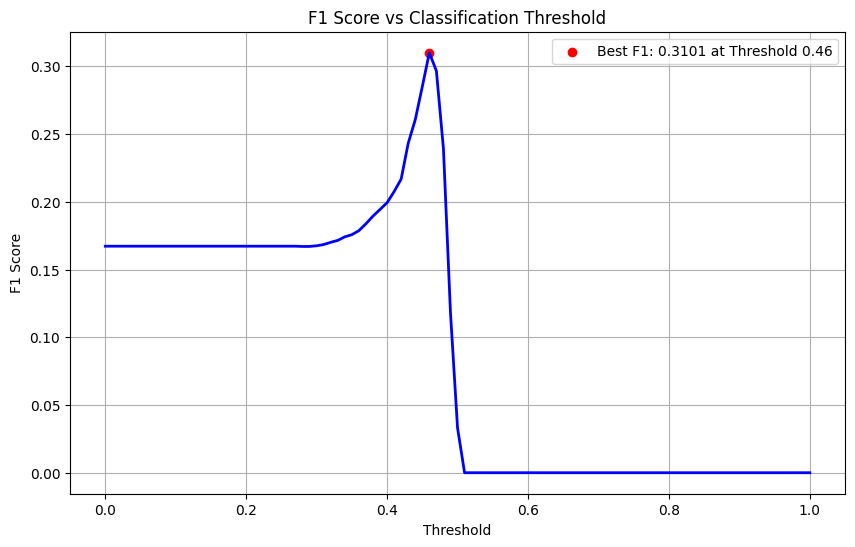

In [1]:
import warnings
from sklearn.exceptions import UndefinedMetricWarning

# Suppress UndefinedMetricWarning and FutureWarning globally
warnings.filterwarnings("ignore", category=UndefinedMetricWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

import numpy as np
import pandas as pd
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_predict
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, f1_score, make_scorer
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
from tqdm import tqdm
from tqdm_joblib import tqdm_joblib
from math import prod

# Load the dataset
# Replace the file path with your actual path
data = pd.read_excel("class1_dataset.xlsx")

# Extract the predictors and outcome
X = data.drop('RRI', axis=1)
Y = data['RRI']

# Define the feature indexes to be used as predictors
# Note: Pandas uses 0-based indexing
feature_indexes = [37, 30, 25, 26, 29, 28, 32, 38, 36, 10, 7, 13, 33, 12, 34, 24, 14, 18, 3, 15, 6, 16, 8, 11]

# Select the specified features using .iloc
X_selected = X.iloc[:, feature_indexes]

# Initialize the base estimator for AdaBoost
base_estimator = DecisionTreeClassifier(random_state=42)

# Create a Pipeline with AdaBoost and the base estimator
pipeline = Pipeline([
    ('ada', AdaBoostClassifier(random_state=42, estimator=base_estimator))  # Updated parameter
])

# Define custom scorers with zero_division=0 to prevent warnings
precision_scorer = make_scorer(precision_score, zero_division=0)
f1_scorer = make_scorer(f1_score, zero_division=0)

# Define the scoring metrics
scoring = {
    'roc_auc': 'roc_auc',
    'accuracy': 'accuracy',
    'precision': precision_scorer,  # Use custom scorer
    'f1': f1_scorer  # Use custom scorer
}

# Define the Stratified 10-Fold Cross-Validation
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Calculate the total number of parameter combinations
n_param_combinations = prod([len(v) for v in {
    'ada__n_estimators': [50, 100, 200, 300],
    'ada__learning_rate': [0.01, 0.1, 0.5, 1.0],
    'ada__algorithm': ['SAMME', 'SAMME.R'],
    'ada__estimator__max_depth': [1, 2, 3, 4, 5],
    'ada__estimator__min_samples_split': [2, 5, 10],
    'ada__estimator__min_samples_leaf': [1, 2, 4],
    'ada__estimator__max_features': ['auto', 'sqrt', 'log2', None]
}.values()])
    
# Calculate the total number of iterations
total_iterations = n_param_combinations * cv.get_n_splits(X_selected, Y)

# Define the parameter grid for hyperparameter tuning
param_grid = {
    # AdaBoost parameters
    'ada__n_estimators': [50, 100, 200, 300],
    'ada__learning_rate': [0.01, 0.1, 0.5, 1.0],
    'ada__algorithm': ['SAMME', 'SAMME.R'],
    
    # Decision Tree parameters (base_estimator -> estimator)
    'ada__estimator__max_depth': [1, 2, 3, 4, 5],
    'ada__estimator__min_samples_split': [2, 5, 10],
    'ada__estimator__min_samples_leaf': [1, 2, 4],
    'ada__estimator__max_features': ['auto', 'sqrt', 'log2', None]
}

# Initialize Grid Search with cross-validation
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring=scoring,
    refit='roc_auc',  # Use 'roc_auc' to select the best model
    cv=cv,
    n_jobs=-1,  # Use all available cores
    verbose=0,  # Disable sklearn's verbose
    return_train_score=False
)

# Fit the Grid Search to the data with progress bar
print("Starting Grid Search...")
with tqdm_joblib(tqdm(desc="Grid Search Progress", total=total_iterations)):
    grid_search.fit(X_selected, Y)
print("Grid Search Completed.")

# Retrieve the best average AUC and its standard deviation
best_auc = grid_search.best_score_
# Retrieve the standard deviation from cv_results_
# Identify the index of the best parameter set
best_index = grid_search.best_index_
best_auc_std = grid_search.cv_results_['std_test_roc_auc'][best_index]

# Retrieve the best hyperparameters
best_params = grid_search.best_params_

# Retrieve the other metrics for the best parameter set
best_accuracy = grid_search.cv_results_['mean_test_accuracy'][best_index]
best_accuracy_std = grid_search.cv_results_['std_test_accuracy'][best_index]

best_precision = grid_search.cv_results_['mean_test_precision'][best_index]
best_precision_std = grid_search.cv_results_['std_test_precision'][best_index]

best_f1 = grid_search.cv_results_['mean_test_f1'][best_index]
best_f1_std = grid_search.cv_results_['std_test_f1'][best_index]

# Output the results
print(f"\nBest Average AUC: {best_auc:.4f} ± {best_auc_std:.4f}")
print(f"Average Accuracy: {best_accuracy:.4f} ± {best_accuracy_std:.4f}")
print(f"Average Precision: {best_precision:.4f} ± {best_precision_std:.4f}")
print(f"Average F1 Score: {best_f1:.4f} ± {best_f1_std:.4f}")
print("\nBest Hyperparameters:")
for param, value in best_params.items():
    print(f"  {param}: {value}")

# Retrieve the best estimator from Grid Search
best_estimator = grid_search.best_estimator_

# Use cross_val_predict to get cross-validated predicted probabilities
# AdaBoost inherently supports predict_proba
print("\nGenerating cross-validated predicted probabilities...")
y_pred_proba = cross_val_predict(best_estimator, X_selected, Y, cv=cv, method='predict_proba', n_jobs=-1)[:, 1]

# Define a range of threshold values to evaluate
thresholds = np.linspace(0.0, 1.0, 101)

# Initialize variables to store the best metrics and threshold
best_threshold = 0.5
best_f1_score = 0.0
best_accuracy = 0.0
best_precision = 0.0

print("Optimizing threshold to maximize F1 score...")

for threshold in thresholds:
    # Convert predicted probabilities to binary predictions based on the threshold
    y_pred = (y_pred_proba >= threshold).astype(int)
    
    # Calculate F1 score
    current_f1 = f1_score(Y, y_pred, zero_division=0)
    
    # Update the best metrics and threshold if current F1 is better
    if current_f1 > best_f1_score:
        best_f1_score = current_f1
        best_threshold = threshold
        best_accuracy = accuracy_score(Y, y_pred)
        best_precision = precision_score(Y, y_pred, zero_division=0)

# Calculate standard deviations using cross-validation
# To compute standard deviations, we'll perform cross-validation predictions and calculate metrics at the best threshold

# Initialize lists to store per-fold metrics
f1_scores = []
accuracies = []
precisions = []

print("\nCalculating metrics at the optimal threshold across folds...")

for fold, (train_idx, test_idx) in enumerate(cv.split(X_selected, Y), 1):
    # Split data
    X_train, X_test = X_selected.iloc[train_idx], X_selected.iloc[test_idx]
    y_train, y_test = Y.iloc[train_idx], Y.iloc[test_idx]
    
    # Fit the model on the training data
    best_estimator.fit(X_train, y_train)
    
    # Predict probabilities on the test data
    y_proba_fold = best_estimator.predict_proba(X_test)[:, 1]
    
    # Apply the optimal threshold
    y_pred_fold = (y_proba_fold >= best_threshold).astype(int)
    
    # Calculate metrics
    fold_f1 = f1_score(y_test, y_pred_fold, zero_division=0)
    fold_accuracy = accuracy_score(y_test, y_pred_fold)
    fold_precision = precision_score(y_test, y_pred_fold, zero_division=0)
    
    # Append to lists
    f1_scores.append(fold_f1)
    accuracies.append(fold_accuracy)
    precisions.append(fold_precision)
    
    print(f"  Fold {fold}: F1={fold_f1:.4f}, Accuracy={fold_accuracy:.4f}, Precision={fold_precision:.4f}")

# Calculate mean and standard deviation for the metrics
mean_f1 = np.mean(f1_scores)
std_f1 = np.std(f1_scores)

mean_accuracy = np.mean(accuracies)
std_accuracy = np.std(accuracies)

mean_precision = np.mean(precisions)
std_precision = np.std(precisions)

# Output the optimized threshold and corresponding metrics
print(f"\n=== Optimized Threshold ===")
print(f"Threshold for Maximum F1 Score: {best_threshold:.2f}")

print(f"\n=== Metrics at Optimal Threshold ===")
print(f"F1 Score: {mean_f1:.4f} ± {std_f1:.4f}")
print(f"Accuracy: {mean_accuracy:.4f} ± {std_accuracy:.4f}")
print(f"Precision: {mean_precision:.4f} ± {std_precision:.4f}")

# Plot F1 Score vs Threshold
f1_scores_plot = []
for threshold in thresholds:
    y_pred = (y_pred_proba >= threshold).astype(int)
    f1 = f1_score(Y, y_pred, zero_division=0)
    f1_scores_plot.append(f1)

plt.figure(figsize=(10, 6))
plt.plot(thresholds, f1_scores_plot, color='blue', lw=2)
plt.scatter(best_threshold, best_f1_score, color='red', 
            label=f'Best F1: {best_f1_score:.4f} at Threshold {best_threshold:.2f}')
plt.title('F1 Score vs Classification Threshold')
plt.xlabel('Threshold')
plt.ylabel('F1 Score')
plt.legend()
plt.grid(True)
plt.show()
